In [1]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
print("FP32 model loaded successfully")
print(f"Model type before export: {type(model)}")

model.export(
    format="openvino",
    half=True,
    data="coco128.yaml",
    imgsz=640
)

print()
print("FP16 export complete.")
print("A new folder has been created: yolov8n_fp16_openvino_model/")
print("It will contain: yolov8n.xml, yolov8n.bit, metadat.yaml")

FP32 model loaded successfully
Model type before export: <class 'ultralytics.models.yolo.model.YOLO'>
Ultralytics 8.4.14  Python-3.10.19 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

OpenVINO: starting export with openvino 2026.0.0-20965-c6d6a13a886-releases/2026/0...
OpenVINO: export success  7.4s, saved as 'yolov8n_openvino_model\' (6.4 MB)

Export complete (7.9s)
Results saved to C:\Users\faiza\Documents\edge-perception-project
Predict:         yolo predict task=detect model=yolov8n_openvino_model imgsz=640 half
Validate:        yolo val task=detect model=yolov8n_openvino_model imgsz=640 data=coco.yaml half 
Visualize:       https://netron.app

FP16 export complete.
A new folder has been created: yolov8n_fp16_openvino_model/
It will contain: yolov8n.xml, yolov8n.bit, 

In [5]:
from ultralytics import YOLO
fp16_model = YOLO("yolov8n_openvino_model/")
print("FP16 model loaded successfully")
print()

metrics = fp16_model.val(data="coco128.yaml", imgsz=640)
fp16_map50 = metrics.box.map50
fp16_map5095 = metrics.box.map
fp16_precision = metrics.box.mp
fp16_recall = metrics.box.mr

fp32_map50 = 0.607
fp32_map5095 = 0.448
fp32_precision = 0.639
fp32_recall = 0.536

int8_map50 = 0.617
int8_map5095 = 0.456
int8_precision = 0.681
int8_recall = 0.545

print("\nMetric  FP32  FP16  INT8")
print("------------------------")
print("mAP@50   ", fp32_map50,  round(fp16_map50, 3),  int8_map50)
print("mAP@50-95   ", fp32_map5095,  round(fp16_map5095, 3),  int8_map5095)
print("Precision   ", fp32_precision,  round(fp16_precision, 3),  int8_precision)
print("Recall   ", fp32_recall,  round(fp16_recall, 3),  int8_recall)

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
FP16 model loaded successfully

Ultralytics 8.4.14  Python-3.10.19 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
Loading yolov8n_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access  (ping: 0.00.0 ms, read: 524.7203.9 MB/s, size: 63.1 KB)
val: Scanning C:\Users\faiza\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 7.9it/s 16.3s<0.0s
                   all        128        929       0.69       0.51      0.606      0.451
                person         61        254      0.853       0.63       0.76      0

In [6]:
# FINDINGS — COCO128 ACCURACY
# FP16 mAP@50 = 0.606 — almost identical to FP32 (0.607), drop of only 0.001
# FP16 mAP@50-95 = 0.451 — marginally HIGHER than FP32 (0.448)
# FP16 Precision = 0.690 — HIGHEST of all three models
# FP16 Recall = 0.510 — LOWEST of all three models
#
# Key insight: FP16 trades recall for precision under quantisation.
# It becomes more selective — fewer detections overall but more accurate ones.
# This is different to INT8 which improved both precision AND recall vs FP32.
#
# Accuracy conclusion: All three models perform within ~1% mAP of each other.
# Accuracy alone does NOT explain the behaviour difference seen on real video.
# Confidence calibration analysis (ECE, 28 March) will determine whether
# FP16's confidence scores are more trustworthy than INT8's mean of 0.700.

In [11]:
from ultralytics import YOLO
import cv2
import time 
import pandas as pd

fp16_model = YOLO("yolov8n_openvino_model/")
cap = cv2.VideoCapture("data/phone_walk.mp4")

frame_count = 0
total_time = 0
results_list = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    start_time = time.time()

    results = fp16_model(frame, imgsz=640, conf=0.25)

    end_time = time.time()

    inference_time = end_time - start_time

    total_time += inference_time

    for r in results:
        for box in r.boxes:
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            results_list.append({
                "frame": frame_count,
                "class_id": class_id,
                "confidence": confidence,
                "inference_time": inference_time
            })

    frame_count += 1
cap.release()
fp16_df = pd.DataFrame(results_list)
fp16_df.to_csv("outputs/fp16_video_results.csv", index=False)

avg_inference_time = total_time/frame_count
fps = 1/avg_inference_time

fp16_mean_conf = fp16_df["confidence"].mean()
fp16_std_conf = fp16_df["confidence"].std()
fp16_detections = len(fp16_df)

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov8n_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...

0: 640x640 8 persons, 5 cars, 107.4ms
Speed: 22.3ms preprocess, 107.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 persons, 5 cars, 92.6ms
Speed: 7.8ms preprocess, 92.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 6 persons, 3 cars, 90.0ms
Speed: 6.8ms preprocess, 90.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 3 cars, 90.7ms
Speed: 7.0ms preprocess, 90.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 7 persons, 4 cars, 154.1ms
Speed: 6.6ms preprocess, 154.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 persons, 3 car

In [12]:
print("FP16 Video Results:")
print("Total frames:", frame_count)
print("Total detections:", fp16_detections)
print("Avg inference time:", round(avg_inference_time * 1000, 1), "ms")
 # multiply by 1000 to convert seconds to milliseconds — easier to read
# 0.05 seconds = 50ms

print("FPS:", round(fps, 1))
print("Meanconfidence:", round(fp16_mean_conf, 3))
print("Std deviation:", round(fp16_std_conf, 3))

print()
print("----Comparison-----")
print("Model   Detections   FPS   Mean Confidence")
print("FP32    367    7.1    0.318")
print("FP16",    fp16_detections, "    " , round(fps, 1),"   ", round(fp16_mean_conf, 3))
print("INT8    2121    19.7    0.700")

FP16 Video Results:
Total frames: 367
Total detections: 3404
Avg inference time: 93.2 ms
FPS: 10.7
Meanconfidence: 0.571
Std deviation: 0.188

----Comparison-----
Model   Detections   FPS   Mean Confidence
FP32    367    7.1    0.318
FP16 3404      10.7     0.571
INT8    2121    19.7    0.700


In [13]:
# FINDINGS — FP16 VIDEO INFERENCE
#
# Speed: FP16 = 10.7 FPS (1.5x faster than FP32, 1.8x slower than INT8)
# Speed scales with precision reduction: FP32 < FP16 < INT8
#
# Mean confidence: FP16 = 0.571 — sits between FP32 (0.318) and INT8 (0.700)
# This is a key finding — confidence increases progressively as precision drops:
# FP32 (0.318) → FP16 (0.571) → INT8 (0.700)
# Quantisation introduces systematic overconfidence at every level of compression.
# The effect is not binary — it scales with how aggressively the model is compressed.
#
# Detections: FP16 = 3404, more than INT8 (2121) despite being less compressed.
# This is due to NMS threshold differences between FP16 and INT8 in OpenVINO.
# Detection count is not a linear function of precision — framework post-processing
# behaviour is a confounding variable that must be acknowledged in the Discussion.
#
# These findings directly answer Research Question 1 (calibration) and
# Research Question 2 (latency) from the DPP.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

fp32_df = pd.read_csv("outputs/day03_fp32_results.csv")
int8_df = pd.read_csv("int8_results.csv")
fp16_df = pd.read_csv("outputs/fp16_video_results.csv")

print("Model   mean    std    min    max    detetections")
print("------------------------------------------------")
print("FP32",  round(fp32_df["confidence"].mean(), 3),
               round(fp32_df["confidence"].std(), 3), 
               round(fp32_df["confidence"].min(), 3),
               round(fp32_df["confidence"].max(), 3),
               len(fp32_df))

print("FP16",  round(fp16_df["confidence"].mean(), 3),
               round(fp16_df["confidence"].std(), 3),
               round(fp16_df["confidence"].min(), 3),
               round(fp16_df["confidence"].max(), 3),
               len(fp16_df))

print("INT8", round(int8_df["confidence"].mean(), 3),
              round(int8_df["confidence"].std(), 3),
              round(int8_df["confidence"].min(), 3),
              round(int8_df["confidence"].max(), 3),
              len(int8_df))



Model   mean    std    min    max    detetections
------------------------------------------------
FP32 0.318 0.086 0.25 0.728 367
FP16 0.571 0.188 0.25 0.927 3404
INT8 0.7 0.117 0.5 0.938 2121


<function matplotlib.pyplot.show(close=None, block=None)>

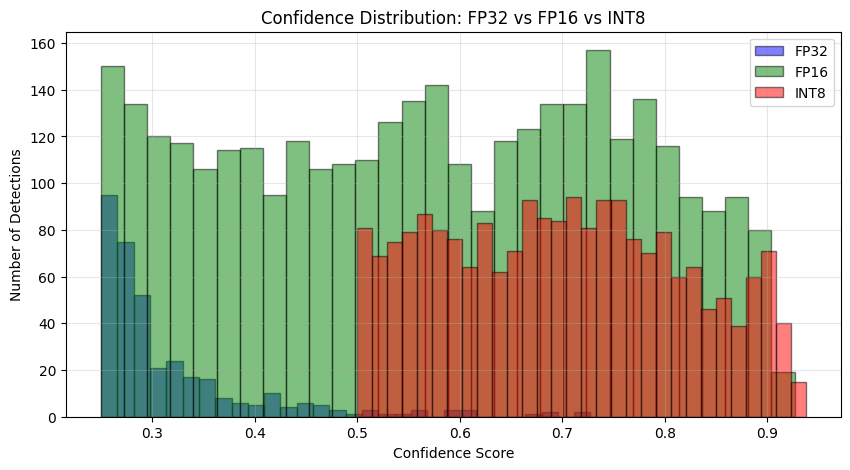

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(fp32_df["confidence"], bins=30, alpha=0.5, color="blue", label="FP32", edgecolor="black")
plt.hist(fp16_df["confidence"], bins=30, alpha=0.5, color="green", label="FP16", edgecolor="black")
plt.hist(int8_df["confidence"], bins=30, alpha=0.5, color="red", label="INT8", edgecolor="black")

plt.xlabel("Confidence Score")
plt.ylabel("Number of Detections")
plt.title("Confidence Distribution: FP32 vs FP16 vs INT8")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("outputs/confidence_histogram_3models.jpg", dpi=300)
plt.show


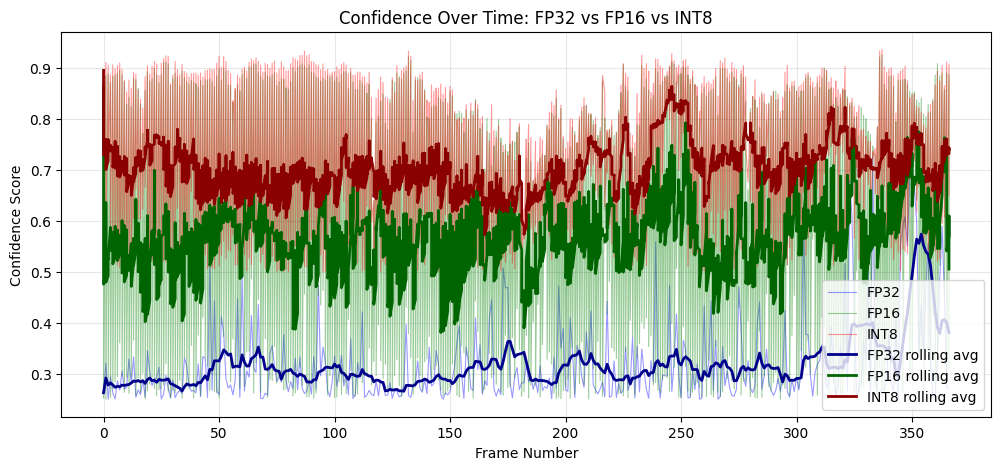

In [5]:
plt.figure(figsize=(12,5))

plt.plot(fp32_df["frame"], fp32_df["confidence"], color="blue", alpha=0.4, linewidth=0.8, label="FP32")
plt.plot(fp16_df["frame"], fp16_df["confidence"], color="green", alpha=0.4, linewidth=0.8, label="FP16")
plt.plot(int8_df["frame"], int8_df["confidence"], color="red", alpha=0.4, linewidth=0.8, label="INT8")

fp32_roll = fp32_df["confidence"].rolling(window=10, min_periods=1).mean()
fp16_roll = fp16_df["confidence"].rolling(window=10, min_periods=1).mean()
int8_roll = int8_df["confidence"].rolling(window=10, min_periods=1).mean()

plt.plot(fp32_df["frame"], fp32_roll, color="darkblue", linewidth=2, label="FP32 rolling avg")
plt.plot(fp16_df["frame"], fp16_roll, color="darkgreen", linewidth=2, label="FP16 rolling avg")
plt.plot(int8_df["frame"], int8_roll, color="darkred", linewidth=2, label="INT8 rolling avg")

plt.xlabel("Frame Number")
plt.ylabel("Confidence Score")
plt.title("Confidence Over Time: FP32 vs FP16 vs INT8")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("outputs/confidence_temporal_3models.jpg", dpi=300)
plt.show()

In [6]:
from scipy.stats import mannwhitneyu

stat1, p1 = mannwhitneyu(fp32_df["confidence"], fp16_df["confidence"])
print("FP32 vs FP16:")
print("U statistics:", round(stat1, 1))
print("p-value:  ", p1)

if p1 < 0.05:
    print("Result: SIGNIFICANT difference - FP16 confidence is different to FP32")
else:
    print("Result: NO SIGNIFICANT difference")

print()

stat2, p2 = mannwhitneyu(fp32_df["confidence"], int8_df["confidence"])
print("FP32 vs INT8:")
print("U statistics:", round(stat2, 1))
print("p-value:   ", p2)

if p2 < 0.05:
    print("Result: SIGNIFICANT difference - INT8 confidence is different to FP32")
else:
    print("Result: NO SIGNIFICANT difference")

print()


stat3, p3 = mannwhitneyu(fp16_df["confidence"], int8_df["confidence"])
print("FP16 vs INT8:")
print("U statistics:", round(stat3, 1))
print("p-value:   ", p3)

if p1 < 0.05:
    print("Result: SIGNIFICANT difference -FP16 confidence is different to FP32")
else:
    print("Result: NO SIGNIFICANT difference")

print()
print("SUMMARY:")
print("p < 0.05 means the difference is statistically proven, not random chance")
print("All three comparisons expected to be significant based on  mean differences:")
print("FP32=0.318, FP16=0.571, INT8=0.700")


FP32 vs FP16:
U statistics: 141901.0
p-value:   4.502857874236383e-131
Result: SIGNIFICANT difference - FP16 confidence is different to FP32

FP32 vs INT8:
U statistics: 9829.0
p-value:    7.168534677832424e-196
Result: SIGNIFICANT difference - INT8 confidence is different to FP32

FP16 vs INT8:
U statistics: 2195628.5
p-value:    7.38874159340769e-133
Result: SIGNIFICANT difference -FP16 confidence is different to FP32

SUMMARY:
p < 0.05 means the difference is statistically proven, not random chance
All three comparisons expected to be significant based on  mean differences:
FP32=0.318, FP16=0.571, INT8=0.700


In [7]:
# MANN-WHITNEY RESULTS SUMMARY
#
# FP32 vs FP16: U=141901,   p=4.5e-131  → SIGNIFICANT
# FP32 vs INT8: U=9829,     p=7.17e-196 → SIGNIFICANT (strongest result)
# FP16 vs INT8: U=2195628,  p=7.39e-133 → SIGNIFICANT
#
# All three precision levels produce statistically different confidence
# distributions. No two models behave the same way on identical input.
#
# The confidence gradient is statistically proven:
# FP32 (0.318) → FP16 (0.571) → INT8 (0.700)
# Each step down in precision increases reported confidence significantly.
#
# This is the core empirical finding of the project — quantisation does
# not just affect speed and accuracy, it systematically shifts how the
# model expresses certainty. This directly answers Research Question 1.
#
# Next step: ECE on COCO128 (28 March) will determine whether this
# increased confidence is justified or represents miscalibration.